# Personal Loan Acceptance Prediction

## Objective
The objective of this project is to predict whether a customer is likely to accept a personal loan offer based on demographic and marketing-related information.

## Dataset
Bank Marketing Dataset (UCI Machine Learning Repository)

## Problem Statement
Banks often run marketing campaigns to offer personal loans to customers. Predicting which customers are likely to accept a loan offer can help improve marketing efficiency and increase conversion rates.

In [97]:
#Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Dataset Understanding and Description

The dataset contains customer information such as age, job, marital status, education level, and previous marketing campaign details.

Target Variable:
y → Whether the customer accepted the loan offer (yes/no)

In [98]:
df = pd.read_csv("bank.csv")

### Dataset Information

In [99]:
df.shape

(11162, 17)

In [100]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [101]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'deposit']

In [102]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [104]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


## Data Cleaning and Preparation

In this step, missing values and categorical variables are handled to prepare the data for machine learning models.

In [105]:
#Chceking Missing Values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


### Encoding Categorail Columns

In [106]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [107]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


## Exploratory Data Analysis

EDA helps understand customer demographics and relationships between features and loan acceptance.

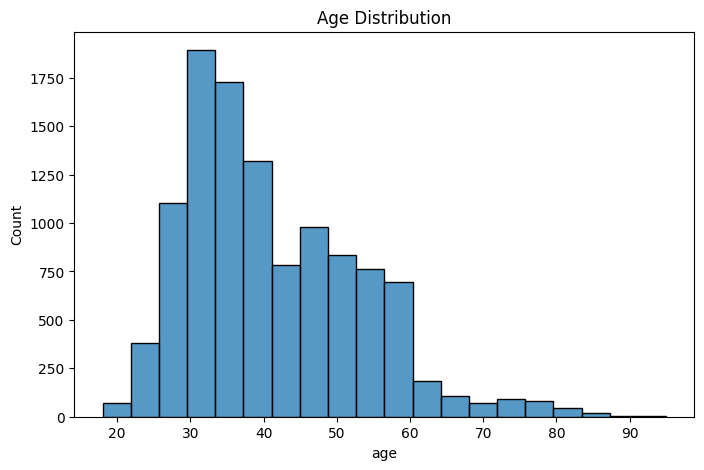

In [108]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20)

plt.title("Age Distribution")
plt.show()

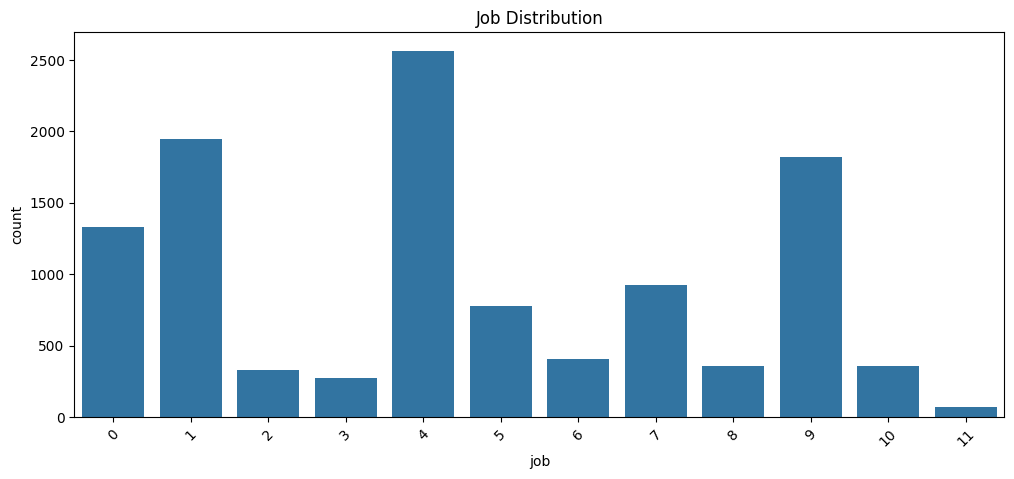

In [109]:
#Job Analysis
plt.figure(figsize=(12,5))

sns.countplot(x='job', data=df)

plt.xticks(rotation=45)

plt.title("Job Distribution")
plt.show()

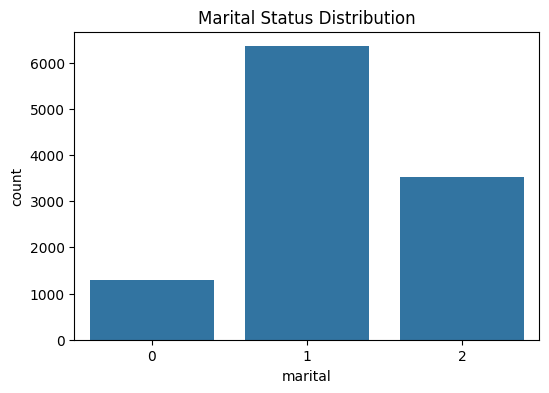

In [110]:
#Marital Status Analysis
plt.figure(figsize=(6,4))

sns.countplot(x='marital', data=df)

plt.title("Marital Status Distribution")
plt.show()

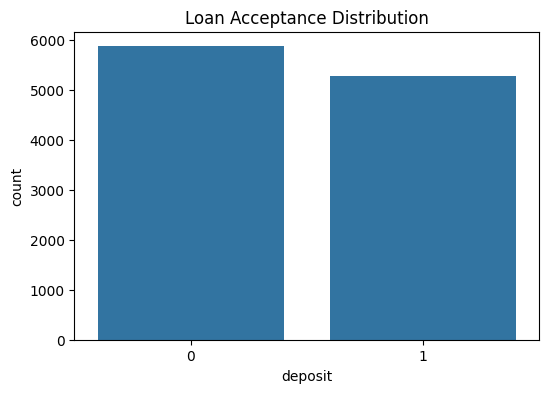

In [111]:
#Target Variables
plt.figure(figsize=(6,4))

sns.countplot(x='deposit', data=df)

plt.title("Loan Acceptance Distribution")

plt.show()

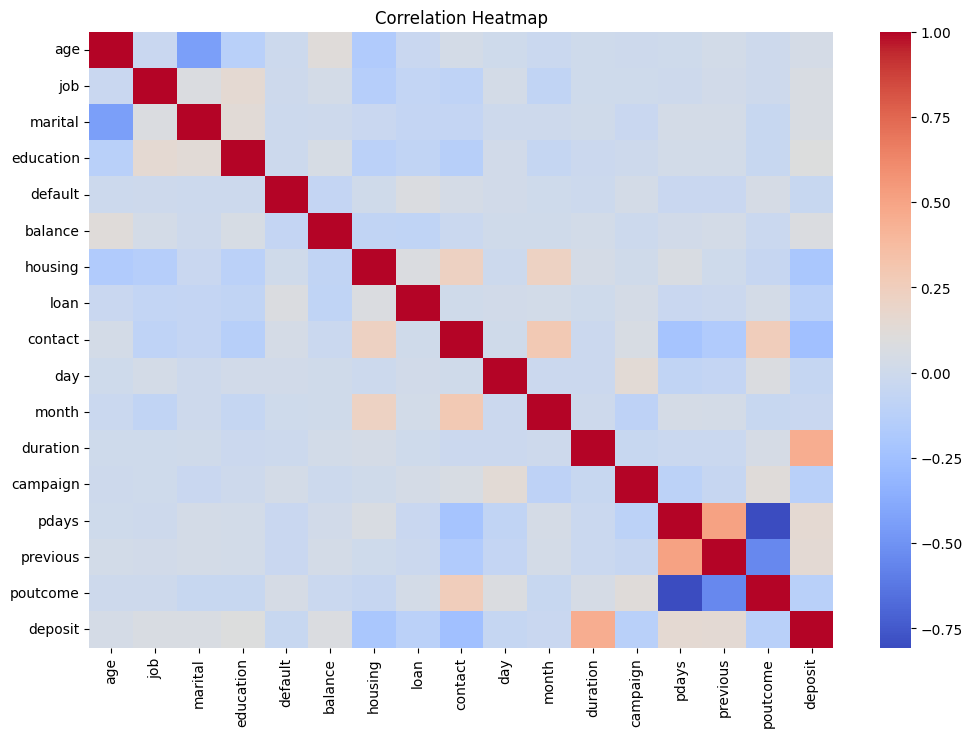

In [112]:
#Corealtion Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=False,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [113]:
#Loan Acceptance by Marital Status
pd.crosstab(df['marital'], df['deposit'])

deposit,0,1
marital,,
0,671,622
1,3596,2755
2,1606,1912


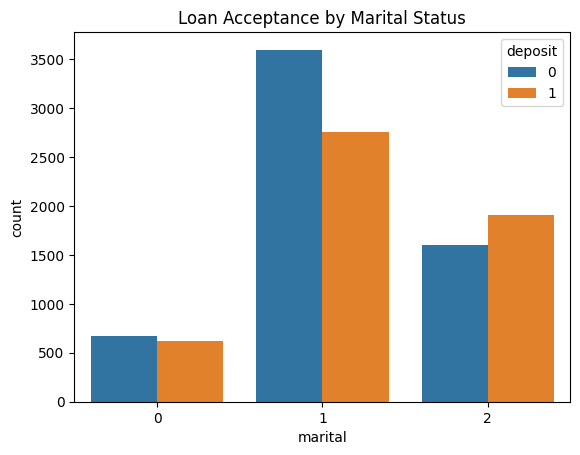

In [114]:
#Visuaization
sns.countplot(x='marital', hue='deposit', data=df)

plt.title("Loan Acceptance by Marital Status")
plt.show()

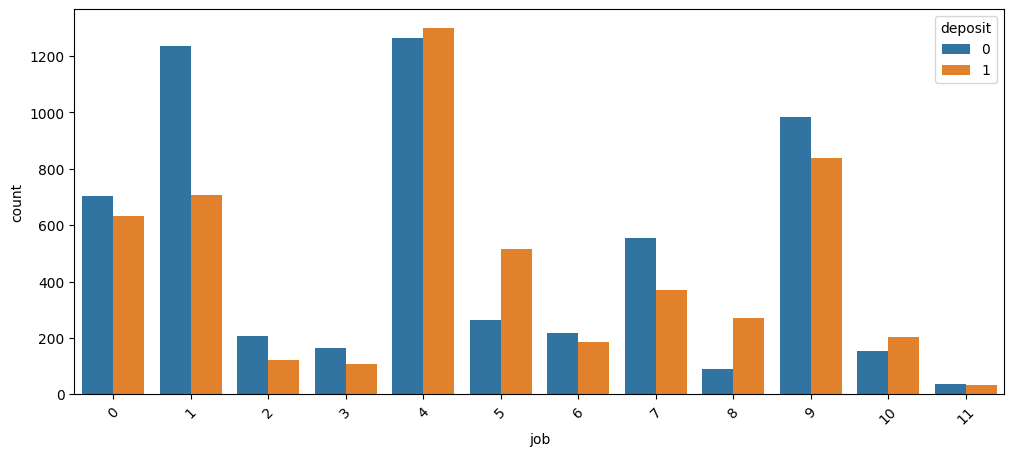

In [115]:
#Loan Acceptance by Job
plt.figure(figsize=(12,5))

sns.countplot(x='job', hue='deposit', data=df)

plt.xticks(rotation=45)

plt.show()

## Feature Selection

The target variable (deposit) is separated from the independent variables for model training.

### Train-Test Split

In [116]:
from sklearn.model_selection import train_test_split

X = df.drop('deposit', axis=1)

y = df['deposit']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [117]:
print(X_train.shape)
print(X_test.shape)

(8929, 16)
(2233, 16)


## Model Training

Logistic Regression is used to predict whether a customer will accept the personal loan offer.

In [118]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [119]:
#Predictions
y_pred = model.predict(X_test)

## Model Evaluation

The model is evaluated using Accuracy Score, Confusion Matrix, and Classification Report.

In [120]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7881773399014779


In [121]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[953 213]
 [260 807]]


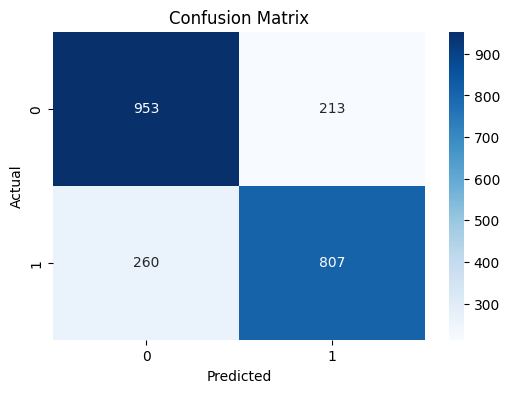

In [122]:
#Confusion Matrix Visualization
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [123]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1166
           1       0.79      0.76      0.77      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



## Decision Tree Classifier

In [124]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

In [125]:
#Accuracy
tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.7630989699955217


In [126]:
#Comparing both Models
print("Logistic Regression Accuracy:", accuracy)

print("Decision Tree Accuracy:", tree_accuracy)

Logistic Regression Accuracy: 0.7881773399014779
Decision Tree Accuracy: 0.7630989699955217


## Business Insights

1. The model successfully predicts customers who are likely to accept a personal loan offer.

2. Customer demographics such as age, job type, and marital status influence loan acceptance.

3. Marketing campaigns can focus on customer groups with higher acceptance probabilities.

4. Predictive analytics can help banks reduce marketing costs and improve campaign effectiveness.

## Conclusion

This project developed a classification model to predict personal loan acceptance using customer demographic and campaign data.

Exploratory Data Analysis was performed to understand customer characteristics. Logistic Regression was used to build the prediction model, and performance was evaluated using accuracy, confusion matrix, and classification metrics.

The results demonstrate how machine learning can support banks in identifying potential customers and improving marketing strategies.